done


/var/folders/bv/57rq_c3j2n5940c90h49cybc0000gn/T/ipykernel_90490/1959768895.py:17: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  X = np.random.multivariate_normal(mean, cov, n_points)


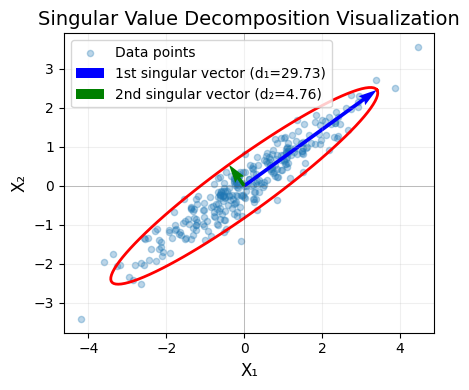

Singular values: d₁ = 29.725, d₂ = 4.762
Ratio d₁/d₂ = 6.243


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

# Set random seed for reproducibility
np.random.seed(42)

print("done")

# Generate 2D Gaussian data with non-zero covariance
n_points = 300
mean = [0, 0]
cov = [[2.0, 1.5],
       [1.5, 1.0]]

# Generate data
X = np.random.multivariate_normal(mean, cov, n_points)

# Compute SVD
U, S, Vt = np.linalg.svd(X, full_matrices=False)

# Get singular vectors (columns of V, or rows of Vt)
v1 = Vt[0, :]  # First singular vector
v2 = Vt[1, :]  # Second singular vector

# Scale singular vectors by singular values for visualization
s1 = S[0]
s2 = S[1]

# Create 95% confidence ellipse
# For 2D Gaussian, 95% corresponds to chi-square with 2 df
chi2_val = chi2.ppf(0.95, df=2)
scale = np.sqrt(chi2_val / n_points)

# Generate ellipse points
theta = np.linspace(0, 2*np.pi, 100)
ellipse_x = scale * s1 * np.cos(theta)
ellipse_y = scale * s2 * np.sin(theta)

# Rotate ellipse by V^T
ellipse_points = np.column_stack([ellipse_x, ellipse_y]) @ Vt

# Create figure
fig, ax = plt.subplots(figsize=(6, 4))

# Plot data points
ax.scatter(X[:, 0], X[:, 1], alpha=0.3, s=20, label='Data points')

# Plot 95% ellipse
ax.plot(ellipse_points[:, 0], ellipse_points[:, 1], 'r-', linewidth=2)

# Plot singular vectors scaled by singular values
origin = [0, 0]
ax.quiver(*origin, v1[0]*s1*scale, v1[1]*s1*scale,
          angles='xy', scale_units='xy', scale=1, color='blue', width=0.01,
          label=f'1st singular vector (d₁={s1:.2f})')
ax.quiver(*origin, v2[0]*s2*scale, v2[1]*s2*scale,
          angles='xy', scale_units='xy', scale=1, color='green', width=0.01,
          label=f'2nd singular vector (d₂={s2:.2f})')

# Add labels and formatting
ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)
ax.axvline(x=0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)
ax.set_xlabel('X₁', fontsize=12)
ax.set_ylabel('X₂', fontsize=12)
ax.set_title('Singular Value Decomposition Visualization', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

fig.savefig("../figures/svd.png")

print(f"Singular values: d₁ = {s1:.3f}, d₂ = {s2:.3f}")
print(f"Ratio d₁/d₂ = {s1/s2:.3f}")